In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import json

In [4]:
skills_df = pd.read_csv("C:/Resume Analyzer/Resume-Evaluator/dataset/technical_skills.csv")

skills_df.head()

,Skill ID,Skill Name,Category
0,1,Python,Programming Languages
1,2,Java,Programming Languages
2,3,C++,Programming Languages
3,4,C#,Programming Languages
4,5,JavaScript,Programming Languages


In [5]:
skills_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Skill ID    528 non-null    int64
 1   Skill Name  528 non-null    str  
 2   Category    528 non-null    str  
dtypes: int64(1), str(2)
memory usage: 25.8 KB


In [6]:
skills_df.isnull().sum()

Skill ID      0
Skill Name    0
Category      0
dtype: int64

In [7]:
skills_df.duplicated().sum()

np.int64(0)

In [9]:
skills_df = skills_df.drop_duplicates()

In [10]:
skills_df.shape

(528, 3)

In [11]:
skills_df.columns

Index(['Skill ID', 'Skill Name', 'Category'], dtype='str')

In [12]:
skills_df['Category'].value_counts()

Category
Programming Languages    100
DevOps & Cloud           100
Web Frameworks            80
Machine Learning & AI     80
Databases                 50
Networking & Security     50
Mobile Development        30
Testing & QA              30
Development Practices      8
Name: count, dtype: int64

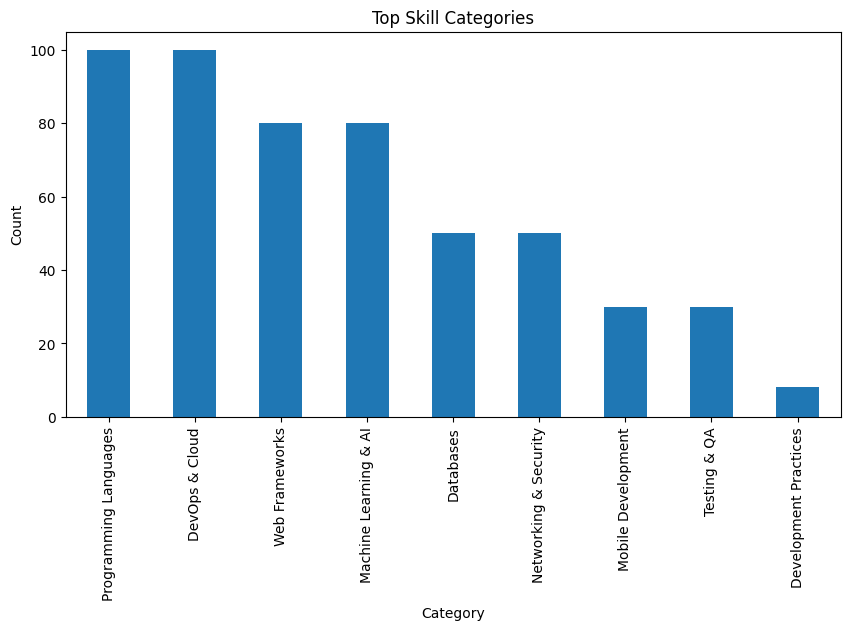

In [13]:
skills_df['Category'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Skill Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

In [14]:
skills_df['Skill Name'] = skills_df['Skill Name'].str.lower()

skills_df.head()

,Skill ID,Skill Name,Category
0,1,python,Programming Languages
1,2,java,Programming Languages
2,3,c++,Programming Languages
3,4,c#,Programming Languages
4,5,javascript,Programming Languages


In [15]:
skills_df['Skill Name'] = skills_df['Skill Name'].str.strip()

skills_df.head()

,Skill ID,Skill Name,Category
0,1,python,Programming Languages
1,2,java,Programming Languages
2,3,c++,Programming Languages
3,4,c#,Programming Languages
4,5,javascript,Programming Languages


In [16]:
skills_df['Skill Name'].nunique()

511

In [17]:
skills_list = skills_df['Skill Name'].unique().tolist()

skills_list[:20]

['python',
 'java',
 'c++',
 'c#',
 'javascript',
 'typescript',
 'php',
 'ruby',
 'swift',
 'go',
 'rust',
 'kotlin',
 'scala',
 'perl',
 'r',
 'matlab',
 'objective-c',
 'dart',
 'elixir',
 'clojure']

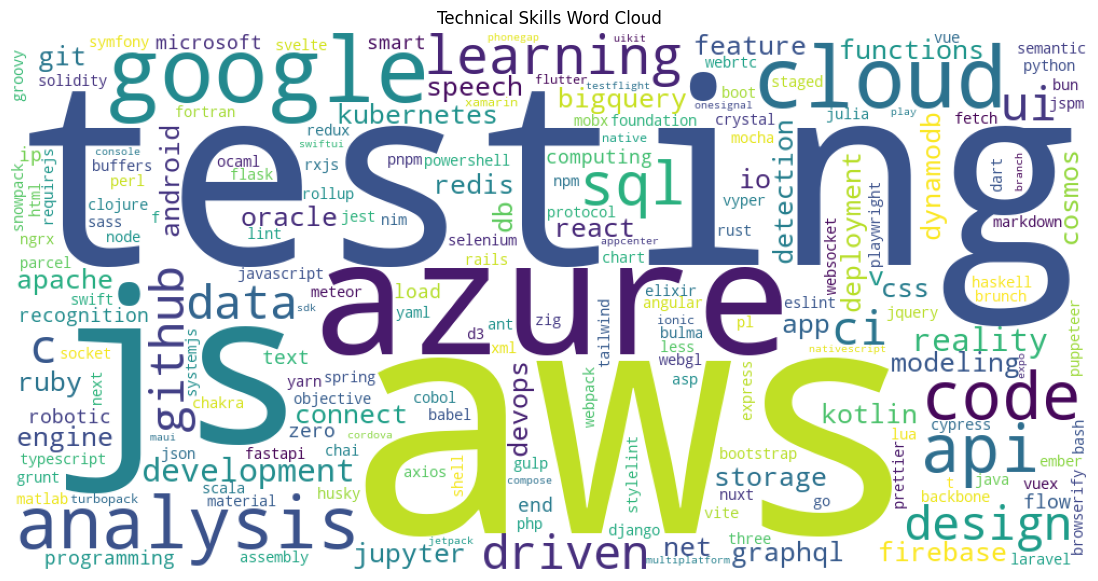

In [18]:
text = " ".join(skills_list)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Technical Skills Word Cloud")

plt.show()

In [20]:
skills_json = {
    "skills": skills_list
}

with open("models/skills.json", "w") as f:
    json.dump(skills_json, f, indent=4)

print("skills.json created successfully")

skills.json created successfully


In [21]:
with open("models/skills.json", "r") as f:
    data = json.load(f)

print(data['skills'][:20])

['python', 'java', 'c++', 'c#', 'javascript', 'typescript', 'php', 'ruby', 'swift', 'go', 'rust', 'kotlin', 'scala', 'perl', 'r', 'matlab', 'objective-c', 'dart', 'elixir', 'clojure']
